## Instructions:

Create a Python notebook to answer all shown procedures, exercises and analysis in this section.
## Resources:

Download the following datasets: fb_stock_prices_2018.csv 

earthquakes.csv
## Procedures:

9.4 Introduction to Seaborn

9.5 Formatting Plots

9.6 Customizing Visualizations

## Data Analysis:

Introduction to Seaborn -  The first noticeable thing is that the default plots already look clean and professional. It's also designed to work well with pandas or DataFrames, whether these values are categorical or numerical, it is able to handle to make data visualizations quite simpler.

Formatting Plots - This part is all about making the appearance of the graphs better. It introduces on how to add different elements to a graph such as title, labels, suptitles, and etc. It also introduces how to make adjustments to different labels, such as its rotation, to make it easier to read.

Customizing Visualizations - This part is the introduction to using pandas.plotting and how it can create multiple graphs condensed in one plot. It also explores on how to change the diagonal of the matrix to a specific type of graph. Create graphs of a single variable and all of it's past values through the use of lag plot.


## Supplementary Activity:
Using the CSV files provided and what we have learned so far in this module complete the following exercises:

1. Using seaborn, create a heatmap to visualize the correlation coefficients between earthquake magnitude and whether there was a tsunami with the magType of mb.


In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [33]:
fb = pd.read_csv(
'fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
eq = pd.read_csv(
'earthquakes.csv', parse_dates=True
)

In [6]:
eq.info()

<class 'pandas.DataFrame'>
RangeIndex: 9332 entries, 0 to 9331
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mag           9331 non-null   float64
 1   magType       9331 non-null   str    
 2   time          9332 non-null   int64  
 3   place         9332 non-null   str    
 4   tsunami       9332 non-null   int64  
 5   parsed_place  9332 non-null   str    
dtypes: float64(1), int64(2), str(3)
memory usage: 437.6 KB


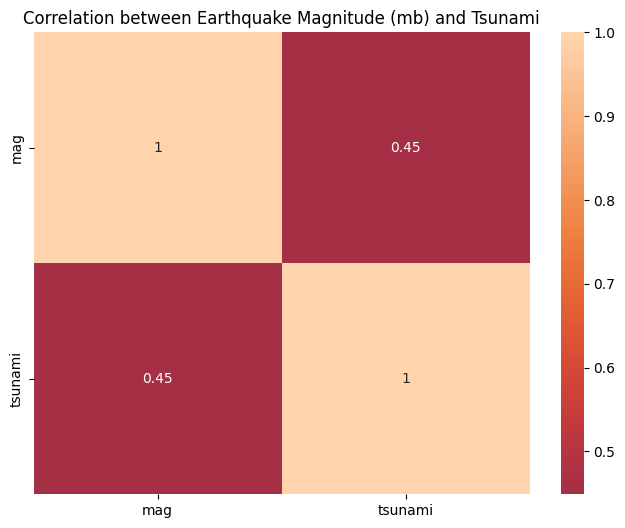

In [8]:
eq_type = eq[eq['magType'] == 'mb']
correlation_data = eq_type[['mag','tsunami']]
correlation = correlation_data.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, center=0)
plt.title('Correlation between Earthquake Magnitude (mb) and Tsunami')
plt.show()

2. Create a box plot of Facebook volume traded and closing prices, and draw reference lines for the bounds of a Tukey fence with a multiplier of 1.5. The bounds will be at Q1 - 1.5 * IQR and Q3 + 1.5 * IQR. Be sure to use the quantile() method on the data to make this easier. (Pick whichever orientation you prefer for the plot, but make sure to use subplots.)

In [18]:
fb.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2018-01-02 to 2018-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    251 non-null    float64
 1   high    251 non-null    float64
 2   low     251 non-null    float64
 3   close   251 non-null    float64
 4   volume  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


Text(0.5, 1.0, 'Facebook Closing Price')

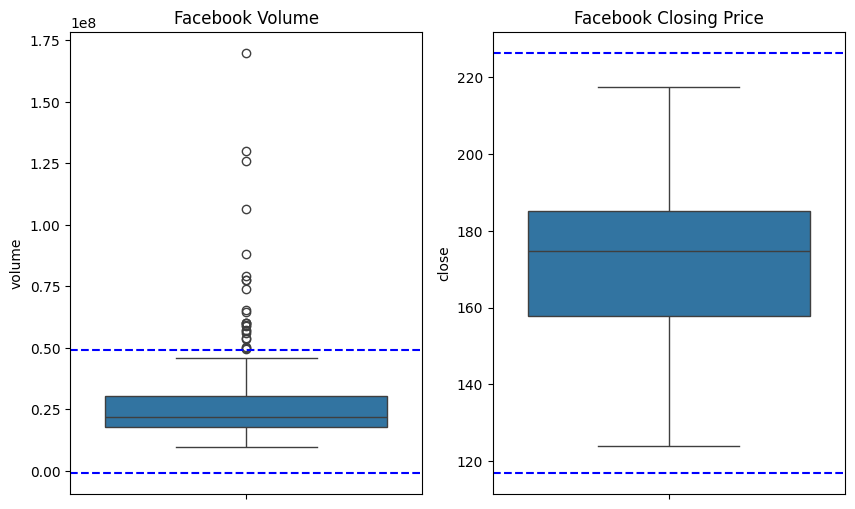

In [12]:
q1 = fb[['volume', 'close']].quantile(0.25)
q3 = fb[['volume', 'close']].quantile(0.75)

iqr = q3 - q1

lowbound = q1 - 1.5*iqr
highbound = q3 + 1.5*iqr

fig, ax = plt.subplots(1,2,figsize=(10,6))

sns.boxplot(y=fb['volume'], ax=ax[0])
ax[0].axhline(lowbound['volume'], color='blue', linestyle='--')
ax[0].axhline(highbound['volume'], color='blue', linestyle='--')
ax[0].set_title('Facebook Volume')

sns.boxplot(y=fb['close'], ax=ax[1])
ax[1].axhline(lowbound['close'], color='blue', linestyle='--')
ax[1].axhline(highbound['close'], color='blue', linestyle='--')
ax[1].set_title('Facebook Closing Price')


3. Fill in the area between the bounds in the plot from exercise #2.

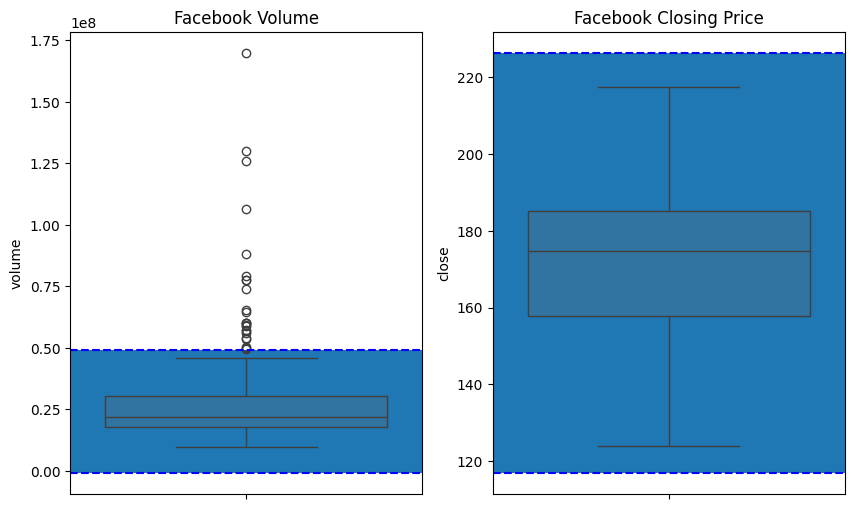

In [15]:
fig, ax = plt.subplots(1,2,figsize=(10,6))
sns.boxplot(y=fb['volume'], ax=ax[0])
ax[0].axhline(lowbound['volume'], color='blue', linestyle='--')
ax[0].axhline(highbound['volume'], color='blue', linestyle='--')
ax[0].set_title('Facebook Volume')
ax[0].axhspan(lowbound['volume'], highbound['volume'])

sns.boxplot(y=fb['close'], ax=ax[1])
ax[1].axhline(lowbound['close'], color='blue', linestyle='--')
ax[1].axhline(highbound['close'], color='blue', linestyle='--')
ax[1].set_title('Facebook Closing Price')
ax[1].axhspan(lowbound['close'], highbound['close'])


4. Use axvspan() to shade a rectangle from '2018-07-25' to '2018-07-31', which marks the large decline in Facebook price on a line plot of the closing price.

In [25]:
print(fb.columns)
fb.head()

Index(['open', 'high', 'low', 'close', 'volume'], dtype='str')


,open,high,low,close,volume
date,,,,,
2018-01-02,177.68,181.58,177.5500,181.42,18151903
2018-01-03,181.88,184.78,181.3300,184.67,16886563
2018-01-04,184.90,186.21,184.0996,184.33,13880896
2018-01-05,185.59,186.90,184.9300,186.85,13574535
2018-01-08,187.20,188.90,186.3300,188.28,17994726


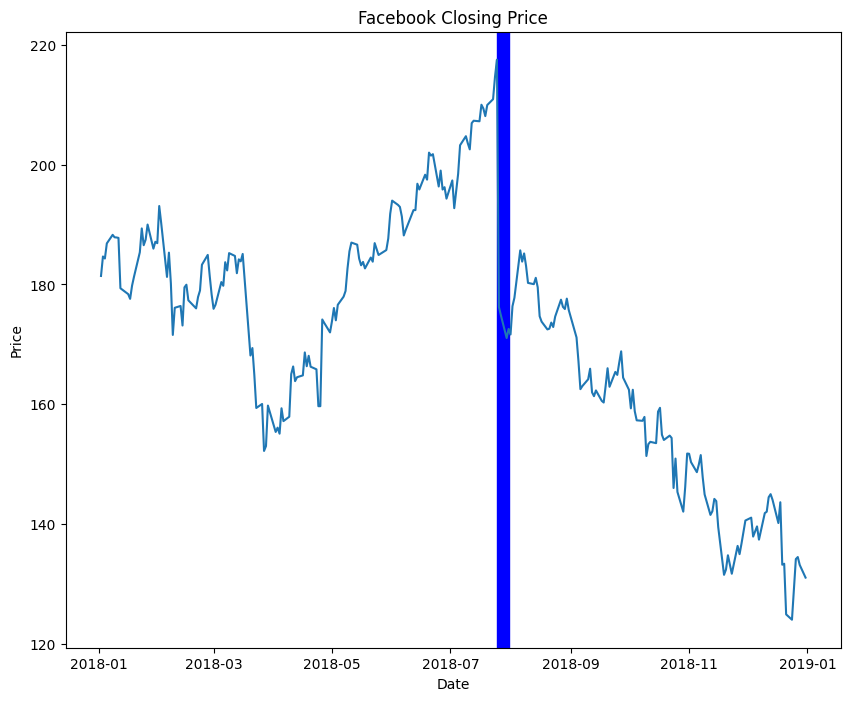

In [35]:
fb.index = pd.to_datetime(fb.index)

plt.figure(figsize=(10,8))
plt.plot(fb.index, fb['close'], label='Closing Price')
plt.axvspan(pd.to_datetime('2018-07-25'), pd.to_datetime('2018-07-31'),
            color='blue')
plt.title('Facebook Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

5. Using the Facebook stock price data, annotate the following three events on a line plot of the closing price:
- Disappointing user growth announced after close on July 25, 2018
- Cambridge Analytica story breaks on March 19, 2018 (when it affected the market)
- FTC launches investigation on March 20, 2018

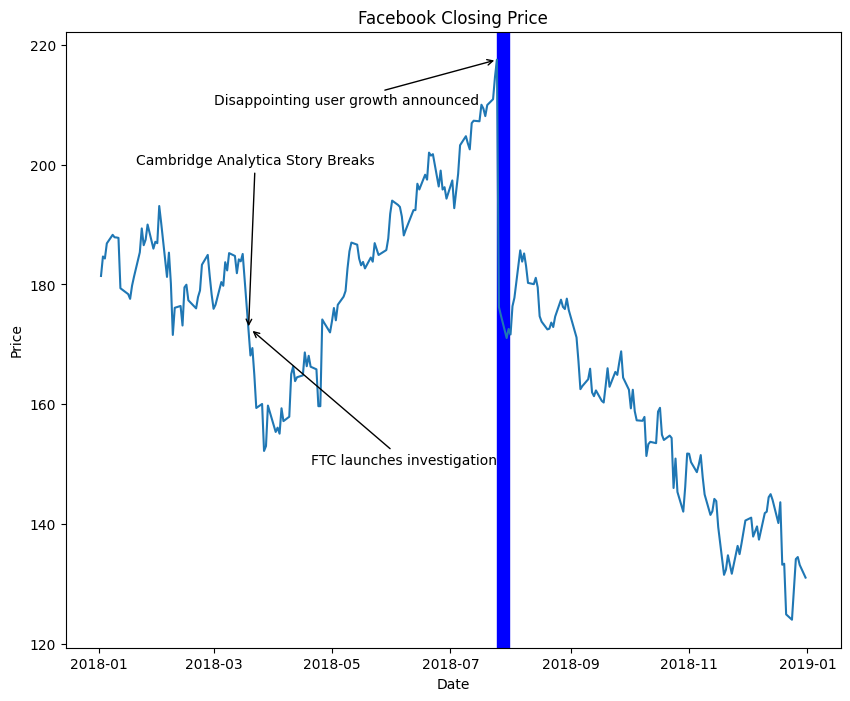

In [55]:
fb.index = pd.to_datetime(fb.index)

plt.figure(figsize=(10,8))
plt.plot(fb.index, fb['close'], label='Closing Price')
plt.axvspan(pd.to_datetime('2018-07-25'), pd.to_datetime('2018-07-31'),
            color='blue')

plt.annotate('Disappointing user growth announced',
             xy=(pd.to_datetime('2018-07-25'), fb.loc['2018-07-25', 'close']),
             xytext=(pd.to_datetime('2018-03-01'),210),
             arrowprops=dict(arrowstyle='->'))

plt.annotate('Cambridge Analytica Story Breaks',
             xy=(pd.to_datetime('2018-03-19'), fb.loc['2018-03-19', 'close']),
             xytext=(pd.to_datetime('2018-01-20'),200),
             arrowprops=dict(arrowstyle='->'))

plt.annotate('FTC launches investigation',
             xy=(pd.to_datetime('2018-03-20'), fb.loc['2018-03-19', 'close']),
             xytext=(pd.to_datetime('2018-04-20'),150),
             arrowprops=dict(arrowstyle='->'))

plt.title('Facebook Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

6. Modify the reg_resid_plots() function to use a matplotlib colormap instead of cycling between two colors. Remember, for this use case, we should pick a qualitative colormap or make our own.

In [56]:
import itertools

def reg_resid_plots(data):
    """
    Using seaborn, plot the regression and residuals
    plots side-by-side for every permutation of 2 columns 
    in the data.
    
    Parameters:
        - data: A pandas DataFrame

    Returns:
        A matplotlib Figure object.
    """
    num_cols = data.shape[1]
    permutation_count = num_cols * (num_cols - 1)

    fig, ax = plt.subplots(permutation_count, 2, figsize=(15, 8))

    cmap= plt.cm.get_cmap('tab10', permutation_count)
    colors= cmap(np.arrange(permutation_count))

    for (x, y), axes, color in zip(
        itertools.permutations(data.columns, 2), 
        ax,
        colors
    ):
        for subplot, func in zip(axes, (sns.regplot, sns.residplot)):
            func(x=x, y=y, data=data, ax=subplot, color=color)

    plt.close()
    return fig

## Summary / Conclusion

It first introduces on the use of Seaborn to make clean and professional looking graphs that is designed to work well with pandas DataFrame. Then it introduces on how to format plots and how it is critical for communication in data science. Then it showed how to make complex layouts of graphs in a single plot.

It serves as practical experience on how to analyze different datasets and how to make the presentation look professional. It also allowed us to explore different functions of seaborn and matplotlib such as axvspan and annotate. It allowed us to make different comparisons through the use of 2 graphs in one plot